# Development of CNNs Models with Log-Mel Spectrogram and MFCC as their input features:

## Imports:

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import ai_edge_litert
import random

In [4]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Geral:

In [5]:
SAMPLE_RATE = 16000
N_FFT = 512
HOP_LENGTH = 160
N_MELS = 64
BATCH_SIZE = 64

CLASS_NAMES = np.array(['go', 'no', 'off', 'on', 'stop', '_unknown_'])
NUM_CLASSES = len(CLASS_NAMES)

AUTOTUNE = tf.data.AUTOTUNE

DATASET_PATH = "../Datasets/KWS/KWS/dataset_augmented/"

In [6]:
def get_label(file_path):
    parts = tf.strings.split(file_path, os.path.sep)
    label = parts[-2]
    return tf.argmax(label == CLASS_NAMES)

In [7]:
def process_audio_log_mel(file_path):
    audio_binary = tf.io.read_file(file_path)
    audio, _ = tf.audio.decode_wav(audio_binary, desired_channels=1)
    audio = tf.squeeze(audio, axis=-1)

    audio = audio[:SAMPLE_RATE]
    audio = tf.pad(audio, [[0, SAMPLE_RATE - tf.shape(audio)[0]]])

    stft = tf.signal.stft(audio, frame_length=N_FFT, frame_step=HOP_LENGTH, fft_length=N_FFT)
    spectrogram = tf.abs(stft)

    num_spectrogram_bins = spectrogram.shape[-1]

    linear_to_mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix(
        num_mel_bins=N_MELS,
        num_spectrogram_bins=num_spectrogram_bins,
        sample_rate=SAMPLE_RATE,
        lower_edge_hertz= 20,
        upper_edge_hertz= SAMPLE_RATE / 2
    )

    mel_spectrogram = tf.tensordot(spectrogram, linear_to_mel_weight_matrix, 1)
    log_mel_spectrogram = tf.math.log(mel_spectrogram + 1e-6)

    means = tf.math.reduce_mean(log_mel_spectrogram)
    stds = tf.math.reduce_std(log_mel_spectrogram)

    log_mel_spectrogram = (log_mel_spectrogram - means) / stds

    return tf.expand_dims(log_mel_spectrogram, -1)

In [8]:
def load_data_log_mel(file_path):
    label = get_label(file_path)
    spectrogram = process_audio_log_mel(file_path)
    return spectrogram, label

In [9]:
def process_audio_MFCC(file_path):
    audio_binary = tf.io.read_file(file_path)
    audio, _ = tf.audio.decode_wav(audio_binary, desired_channels=1)
    audio = tf.squeeze(audio, axis=-1)

    audio = audio[:SAMPLE_RATE]
    audio = tf.pad(audio, [[0, SAMPLE_RATE - tf.shape(audio)[0]]])

    stft = tf.signal.stft(audio, frame_length=N_FFT, frame_step=HOP_LENGTH, fft_length=N_FFT)
    spectrogram = tf.abs(stft)

    num_spectrogram_bins = spectrogram.shape[-1]

    linear_to_mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix(
        num_mel_bins=N_MELS,
        num_spectrogram_bins=num_spectrogram_bins,
        sample_rate=SAMPLE_RATE,
        lower_edge_hertz= 20,
        upper_edge_hertz= SAMPLE_RATE / 2
    )

    mel_spectrogram = tf.tensordot(spectrogram, linear_to_mel_weight_matrix, 1)
    log_mel_spectrogram = tf.math.log(mel_spectrogram + 1e-6)

    means = tf.math.reduce_mean(log_mel_spectrogram)
    stds = tf.math.reduce_std(log_mel_spectrogram)

    log_mel_spectrogram = (log_mel_spectrogram - means) / stds

    mfccs = tf.signal.mfccs_from_log_mel_spectrograms(log_mel_spectrogram)[..., :13]

    return tf.expand_dims(mfccs, -1)

In [10]:
def load_data_MFCC(file_path):
    label = get_label(file_path)
    spectrogram = process_audio_MFCC(file_path)
    return spectrogram, label

In [11]:
train_ds = tf.data.Dataset.list_files(f"{DATASET_PATH}/train/*/*.wav")
val_ds = tf.data.Dataset.list_files(f"{DATASET_PATH}/validation/*/*.wav")
test_ds = tf.data.Dataset.list_files(f"{DATASET_PATH}/test/*/*.wav")

I0000 00:00:1764609005.394324   47223 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9921 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070, pci bus id: 0000:01:00.0, compute capability: 8.9


In [12]:
train_ds_log_mel = (train_ds
    .map(load_data_log_mel, num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

train_ds_MFCC = (train_ds
    .map(load_data_MFCC, num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds_log_mel = (val_ds
    .map(load_data_log_mel, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds_MFCC = (val_ds
    .map(load_data_MFCC, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds_log_mel = (test_ds
    .map(load_data_log_mel, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds_MFCC = (test_ds
    .map(load_data_MFCC, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

Input shape: (64, 97, 64, 1)
Label shape: (64,)


2025-12-01 14:10:06.692176: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


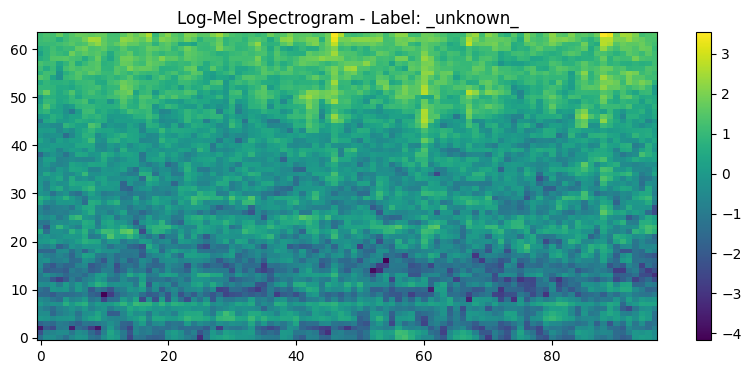

2025-12-01 14:10:06.774595: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [13]:
for spec, label in train_ds_log_mel.take(1):
    input_shape_log_mel = spec[0].shape
    print("Input shape:", spec.shape)
    print("Label shape:", label.shape)
    plt.figure(figsize=(10, 4))
    plt.imshow(tf.transpose(spec[0], perm=[1, 0, 2])[:, :, 0], aspect='auto', origin='lower')
    plt.title(f"Log-Mel Spectrogram - Label: {CLASS_NAMES[label[0]]}")
    plt.colorbar()
    plt.show()

In [14]:
print("Log-Mel Spectrogram input shape:", input_shape_log_mel)

Log-Mel Spectrogram input shape: (97, 64, 1)


Input shape: (64, 97, 13, 1)
Label shape: (64,)


2025-12-01 14:10:07.009112: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


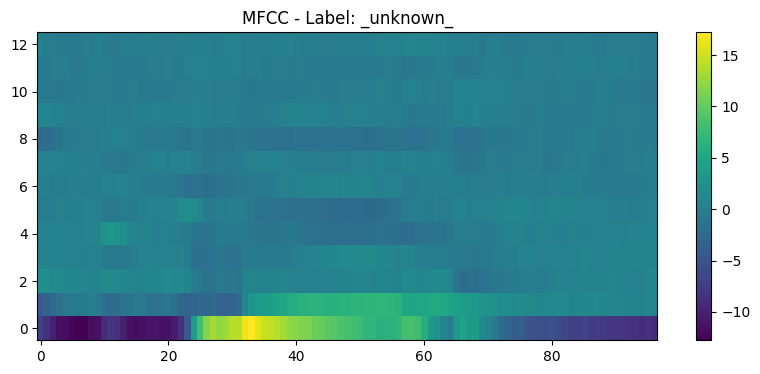

2025-12-01 14:10:07.073912: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [15]:
for spec, label in train_ds_MFCC.take(1):
    input_shape_MFCC = spec[0].shape
    print("Input shape:", spec.shape)
    print("Label shape:", label.shape)
    plt.figure(figsize=(10, 4))
    plt.imshow(tf.transpose(spec[0], perm=[1, 0, 2])[:, :, 0], aspect='auto', origin='lower')
    plt.title(f"MFCC - Label: {CLASS_NAMES[label[0]]}")
    plt.colorbar()
    plt.show()

In [16]:
print("MFCC input shape:", input_shape_MFCC)

MFCC input shape: (97, 13, 1)


## Training:

### Log-Mel Spectrogram:

In [17]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)
random.seed(42)
np.random.seed(42)
os.environ['PYTHONHASHSEED'] = '42'

In [18]:
model_log_mel = tf.keras.models.Sequential([
    # Input:
    tf.keras.layers.Input(input_shape_log_mel),

    # Bloco de Convolução 1
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Bloco de Convolução 2
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Bloco de Convolução 3
    tf.keras.layers.Conv2D(128, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Flatten:
    tf.keras.layers.Flatten(),

    # Bloco Denso para classificação:
    tf.keras.layers.Dense(256),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dense(128),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dense(len(CLASS_NAMES), activation='softmax')
])

model_log_mel.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 97, 64, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 97, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 97, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 48, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 24, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 8, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,293,638 (12.56 MB)

 Trainable params: 3,292,358 (12.56 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [19]:
model_log_mel.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [20]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel_&_MFCC/models/model_log_mel.keras', monitor='val_loss', save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)
]

In [21]:
history_log_mel = model_log_mel.fit(train_ds_log_mel, validation_data=val_ds_log_mel, callbacks=callbacks, epochs=100, verbose=1)

Epoch 1/100


2025-12-01 14:10:09.527752: I external/local_xla/xla/service/service.cc:163] XLA service 0x7cf23c002f70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-01 14:10:09.527766: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4070, Compute Capability 8.9
2025-12-01 14:10:09.559090: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-01 14:10:09.759660: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91600
2025-12-01 14:10:09.798140: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-01 14:10:09.798179: I e

  16/2059 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.4507 - loss: 1.5178

I0000 00:00:1764609012.841999   47341 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2059/2059 ━━━━━━━━━━━━━━━━━━━━ 32s 13ms/step - accuracy: 0.8968 - loss: 0.2908 - val_accuracy: 0.9153 - val_loss: 0.2429 - learning_rate: 0.0010
Epoch 2/100
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9585 - loss: 0.1176 - val_accuracy: 0.9087 - val_loss: 0.2870 - learning_rate: 0.0010
Epoch 3/100
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9739 - loss: 0.0739 - val_accuracy: 0.9397 - val_loss: 0.2309 - learning_rate: 0.0010
Epoch 4/100
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9819 - loss: 0.0510 - val_accuracy: 0.9422 - val_loss: 0.2143 - learning_rate: 0.0010
Epoch 5/100
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9864 - loss: 0.0380 - val_accuracy: 0.9366 - val_loss: 0.3048 - learning_rate: 0.0010
Epoch 6/100
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.9897 - loss: 0.0289 - val_accuracy: 0.9481 - val_loss: 0.2340 - learning_rate: 0.0010
Epoch 7/100
2057/2059 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.

### MFCC:

In [22]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)
random.seed(42)
np.random.seed(42)
os.environ['PYTHONHASHSEED'] = '42'

In [23]:
model_MFCC = tf.keras.models.Sequential([
    # Input:
    tf.keras.layers.Input(input_shape_MFCC),

    # Bloco de Convolução 1
    tf.keras.layers.Conv2D(32, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Bloco de Convolução 2
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Bloco de Convolução 3
    tf.keras.layers.Conv2D(128, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Flatten:
    tf.keras.layers.Flatten(),

    # Bloco Denso para classificação:
    tf.keras.layers.Dense(128),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dense(64),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dense(len(CLASS_NAMES), activation='softmax')
])

model_MFCC.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 97, 13, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 97, 13, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 97, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 6, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 6, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 6, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 48, 6, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 3, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 3, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 3, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 24, 3, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 1, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       196,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 299,718 (1.14 MB)

 Trainable params: 298,886 (1.14 MB)

 Non-trainable params: 832 (3.25 KB)

In [24]:
model_MFCC.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [25]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel_&_MFCC/models/model_MFCC.keras', monitor='val_loss', save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)
]

In [26]:
history_MFCC = model_MFCC.fit(train_ds_MFCC, validation_data=val_ds_MFCC, callbacks=callbacks, epochs=100, verbose=1)

Epoch 1/100


2025-12-01 14:13:42.584925: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-01 14:13:42.584962: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-01 14:13:42.584999: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-01 14:13:42.585007: I external/l

2059/2059 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.8776 - loss: 0.3442 - val_accuracy: 0.9198 - val_loss: 0.2327 - learning_rate: 0.0010
Epoch 2/100
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9425 - loss: 0.1647 - val_accuracy: 0.9269 - val_loss: 0.2165 - learning_rate: 0.0010
Epoch 3/100
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9569 - loss: 0.1207 - val_accuracy: 0.9223 - val_loss: 0.2478 - learning_rate: 0.0010
Epoch 4/100
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9667 - loss: 0.0934 - val_accuracy: 0.9395 - val_loss: 0.1947 - learning_rate: 0.0010
Epoch 5/100
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9725 - loss: 0.0764 - val_accuracy: 0.9391 - val_loss: 0.1885 - learning_rate: 0.0010
Epoch 6/100
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9771 - loss: 0.0637 - val_accuracy: 0.9288 - val_loss: 0.2384 - learning_rate: 0.0010
Epoch 7/100
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9808 - loss:

## Testing:

### Log-Mel Spectrogram:

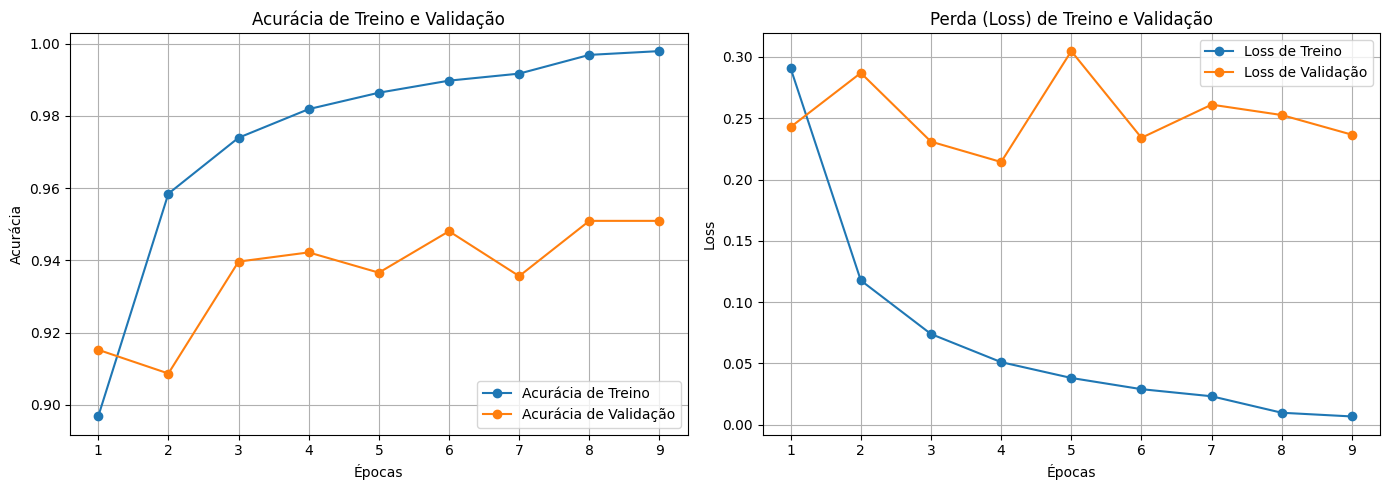

In [27]:
acc = history_log_mel.history['accuracy']
val_acc = history_log_mel.history['val_accuracy']
loss = history_log_mel.history['loss']
val_loss = history_log_mel.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'o-', label='Acurácia de Treino')
plt.plot(epochs_range, val_acc, 'o-', label='Acurácia de Validação')
plt.title('Acurácia de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.grid(True)
plt.legend(loc='lower right')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'o-', label='Loss de Treino')
plt.plot(epochs_range, val_loss, 'o-', label='Loss de Validação')
plt.title('Perda (Loss) de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [28]:
model_log_mel = tf.keras.models.load_model('../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel_&_MFCC/models/model_log_mel.keras')

y_pred_probs = model_log_mel.predict(test_ds_log_mel)
y_pred_indices = np.argmax(y_pred_probs, axis=1)

y_true_indices = np.concatenate([y for x, y in test_ds_log_mel], axis=0)

print("\n--- Relatório de Classificação ---")
report = classification_report(y_true_indices, y_pred_indices, target_names=CLASS_NAMES)
print(report)

63/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

2025-12-01 14:14:34.012511: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-01 14:14:34.221191: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_169', 8 bytes spill stores, 8 bytes spill loads



77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

--- Relatório de Classificação ---
              precision    recall  f1-score   support

          go       0.93      0.86      0.90       402
          no       0.95      0.87      0.91       405
         off       0.91      0.86      0.88       402
          on       0.93      0.89      0.91       396
        stop       0.99      0.92      0.96       411
   _unknown_       0.94      0.98      0.96      2874

    accuracy                           0.94      4890
   macro avg       0.94      0.90      0.92      4890
weighted avg       0.94      0.94      0.94      4890



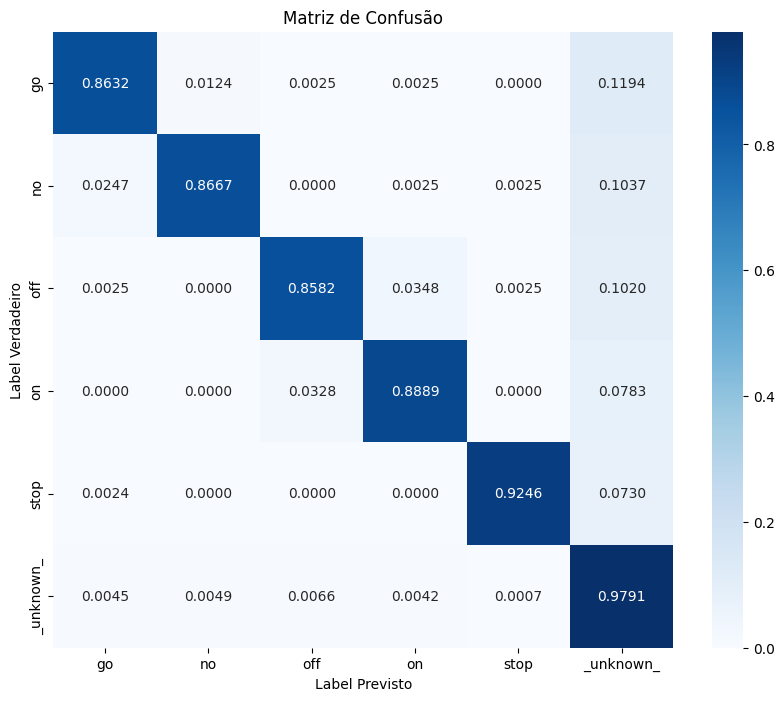

In [29]:
cm = confusion_matrix(y_true_indices, y_pred_indices)
row_sums = cm.sum(axis=1, keepdims=True)
cm_normalized = cm.astype('float') / row_sums

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.4f',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title('Matriz de Confusão')
plt.ylabel('Label Verdadeiro')
plt.xlabel('Label Previsto')
plt.show()

### MFCC:

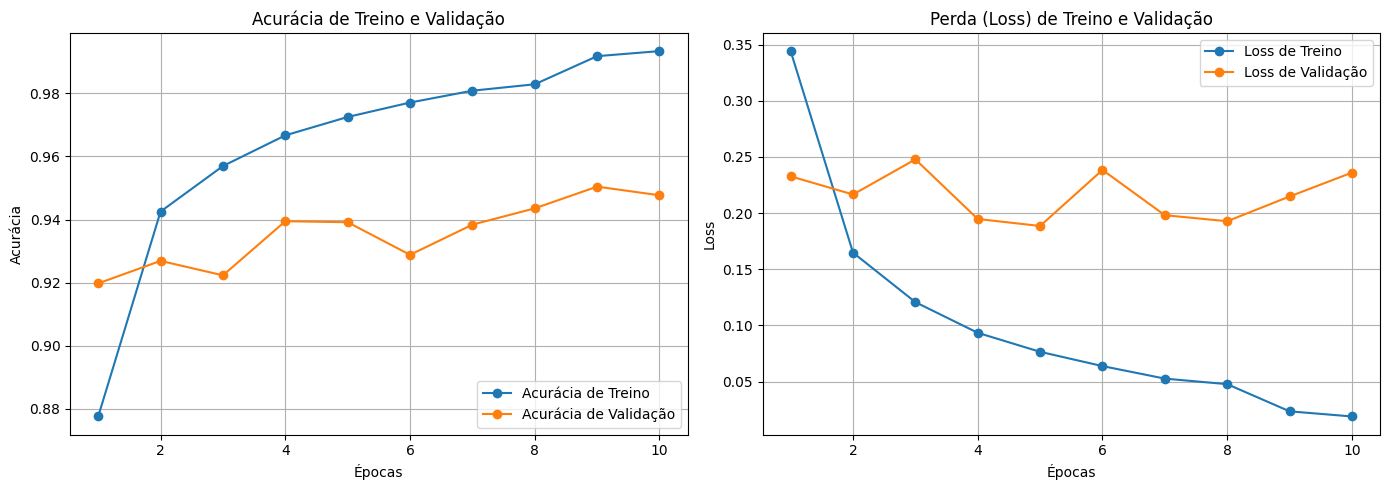

In [30]:
acc = history_MFCC.history['accuracy']
val_acc = history_MFCC.history['val_accuracy']
loss = history_MFCC.history['loss']
val_loss = history_MFCC.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'o-', label='Acurácia de Treino')
plt.plot(epochs_range, val_acc, 'o-', label='Acurácia de Validação')
plt.title('Acurácia de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.grid(True)
plt.legend(loc='lower right')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'o-', label='Loss de Treino')
plt.plot(epochs_range, val_loss, 'o-', label='Loss de Validação')
plt.title('Perda (Loss) de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [31]:
model_MFCC = tf.keras.models.load_model('../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel_&_MFCC/models/model_MFCC.keras')

y_pred_probs = model_MFCC.predict(test_ds_MFCC)
y_pred_indices = np.argmax(y_pred_probs, axis=1)

y_true_indices = np.concatenate([y for x, y in test_ds_MFCC], axis=0)

print("\n--- Relatório de Classificação ---")
report = classification_report(y_true_indices, y_pred_indices, target_names=CLASS_NAMES)
print(report)

64/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

2025-12-01 14:14:35.776263: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-01 14:14:36.020799: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_169', 28 bytes spill stores, 28 bytes spill loads



77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step

--- Relatório de Classificação ---
              precision    recall  f1-score   support

          go       0.91      0.89      0.90       402
          no       0.79      0.97      0.87       405
         off       0.94      0.91      0.92       402
          on       0.93      0.92      0.92       396
        stop       0.98      0.92      0.95       411
   _unknown_       0.96      0.95      0.96      2874

    accuracy                           0.94      4890
   macro avg       0.92      0.92      0.92      4890
weighted avg       0.94      0.94      0.94      4890



2025-12-01 14:14:36.468324: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


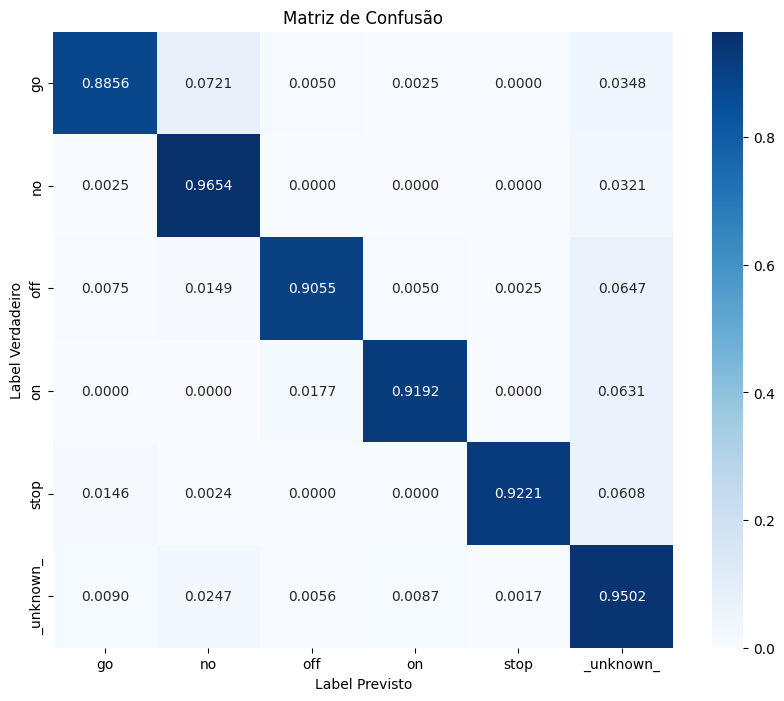

In [32]:
cm = confusion_matrix(y_true_indices, y_pred_indices)
row_sums = cm.sum(axis=1, keepdims=True)
cm_normalized = cm.astype('float') / row_sums

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.4f',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title('Matriz de Confusão')
plt.ylabel('Label Verdadeiro')
plt.xlabel('Label Previsto')
plt.show()

## Gerando modelo .tflite (float16):

### Log-Mel Spectrogram:

In [33]:
keras_model = tf.keras.models.load_model("../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel_&_MFCC/models/model_log_mel.keras")

converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)

print("\nIniciando conversão com quantização Float16...")

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_model_fp16 = converter.convert()

with open("../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel_&_MFCC/models/model_log_mel_fp16.tflite", 'wb') as f:
    f.write(tflite_model_fp16)
print(f"Modelo com Float16 Quantization salvo em ../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel_&_MFCC/models/model_log_mel_fp16.tflite")


Iniciando conversão com quantização Float16...
INFO:tensorflow:Assets written to: /tmp/tmph_n0r107/assets


INFO:tensorflow:Assets written to: /tmp/tmph_n0r107/assets


Saved artifact at '/tmp/tmph_n0r107'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 97, 64, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  137380979688720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137380979693296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137380979703504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137380979738576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137380979698928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137380979701216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137380979751952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137380979752656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137380977809664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137380977805616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137380977807376: 

W0000 00:00:1764609278.588685   47223 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1764609278.588697   47223 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


Modelo com Float16 Quantization salvo em ../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel_&_MFCC/models/model_log_mel_fp16.tflite


2025-12-01 14:14:38.588891: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmph_n0r107
2025-12-01 14:14:38.589525: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-12-01 14:14:38.589529: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmph_n0r107
I0000 00:00:1764609278.596085   47223 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2025-12-01 14:14:38.597303: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-12-01 14:14:38.645722: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmph_n0r107
2025-12-01 14:14:38.656148: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 67258 microseconds.


### MFCC:

In [34]:
keras_model = tf.keras.models.load_model("../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel_&_MFCC/models/model_MFCC.keras")

converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)

print("\nIniciando conversão com quantização Float16...")

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_model_fp16 = converter.convert()

with open("../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel_&_MFCC/models/model_MFCC_fp16.tflite", 'wb') as f:
    f.write(tflite_model_fp16)
print(f"Modelo com Float16 Quantization salvo em ../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel_&_MFCC/models/model_MFCC_fp16.tflite")


Iniciando conversão com quantização Float16...
INFO:tensorflow:Assets written to: /tmp/tmpu_2qu90f/assets


INFO:tensorflow:Assets written to: /tmp/tmpu_2qu90f/assets


Saved artifact at '/tmp/tmpu_2qu90f'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 97, 13, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  137381645888752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137381645739536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137381647588464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137381647581248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137381647587056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137381647594800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137381647583360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137381648285040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137381648277648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137381648275888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137381648269552: 

W0000 00:00:1764609279.357607   47223 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1764609279.357619   47223 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2025-12-01 14:14:39.357699: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpu_2qu90f
2025-12-01 14:14:39.358261: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-12-01 14:14:39.358264: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpu_2qu90f
2025-12-01 14:14:39.364777: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-12-01 14:14:39.406539: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpu_2qu90f
2025-12-01 14:14:39.419585: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 61887 microseconds.


## Testing .tflite model (float16):

### Log-Mel Spectrogram:

In [35]:
TFLITE_MODEL_PATH = Path('../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel_&_MFCC/models/model_log_mel_fp16.tflite')

print(f"Carregando modelo TFLite de: {TFLITE_MODEL_PATH}")
interpreter = tf.lite.Interpreter(model_path=str(TFLITE_MODEL_PATH))

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

print("\n--- Detalhes do Modelo TFLite ---")
print(f"Entrada (Shape): {input_details['shape']}")
print(f"Entrada (Tipo): {input_details['dtype']}")
print(f"Saída (Shape): {output_details['shape']}")
print(f"Saída (Tipo): {output_details['dtype']}")

Carregando modelo TFLite de: ../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel_&_MFCC/models/model_log_mel_fp16.tflite

--- Detalhes do Modelo TFLite ---
Entrada (Shape): [ 1 97 64  1]
Entrada (Tipo): <class 'numpy.float32'>
Saída (Shape): [1 6]
Saída (Tipo): <class 'numpy.float32'>


/home/rolds/Documents/venvs/tensorflow_venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [36]:
y_true = []
y_pred = []
total_samples = 0

print("Iniciando avaliação no dataset de teste...")
for data_batch, labels_batch in test_ds_log_mel:
    # Iterar sobre cada amostra no lote
    for i in range(data_batch.shape[0]):
        # Pegar uma única amostra de dado
        sample_data = data_batch[i]
        
        # Adicionar a dimensão do lote (batch dimension) para corresponder ao shape da entrada do modelo
        input_tensor = np.expand_dims(sample_data, axis=0).astype(np.float32)

        # Definir o tensor de entrada, executar inferência e obter a saída
        # Não precisamos de nenhuma conversão manual, o interpretador cuida de tudo.
        interpreter.set_tensor(input_details['index'], input_tensor)
        interpreter.invoke()
        output_data = interpreter.get_tensor(output_details['index'])
        
        # Armazenar o rótulo previsto e o rótulo verdadeiro
        predicted_label_index = np.argmax(output_data)
        y_pred.append(predicted_label_index)
        y_true.append(labels_batch[i].numpy())
        
    total_samples += data_batch.shape[0]
    print(f"Avaliadas {total_samples} amostras...")

print("\nAvaliação concluída.")

Iniciando avaliação no dataset de teste...
Avaliadas 64 amostras...
Avaliadas 128 amostras...
Avaliadas 192 amostras...
Avaliadas 256 amostras...
Avaliadas 320 amostras...
Avaliadas 384 amostras...
Avaliadas 448 amostras...
Avaliadas 512 amostras...
Avaliadas 576 amostras...
Avaliadas 640 amostras...
Avaliadas 704 amostras...
Avaliadas 768 amostras...
Avaliadas 832 amostras...
Avaliadas 896 amostras...
Avaliadas 960 amostras...
Avaliadas 1024 amostras...
Avaliadas 1088 amostras...
Avaliadas 1152 amostras...
Avaliadas 1216 amostras...
Avaliadas 1280 amostras...
Avaliadas 1344 amostras...
Avaliadas 1408 amostras...
Avaliadas 1472 amostras...
Avaliadas 1536 amostras...
Avaliadas 1600 amostras...
Avaliadas 1664 amostras...
Avaliadas 1728 amostras...
Avaliadas 1792 amostras...
Avaliadas 1856 amostras...
Avaliadas 1920 amostras...
Avaliadas 1984 amostras...
Avaliadas 2048 amostras...
Avaliadas 2112 amostras...
Avaliadas 2176 amostras...
Avaliadas 2240 amostras...
Avaliadas 2304 amostras...
A

In [37]:
print("\n--- Relatório de Classificação ---\n")
report = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
print(report)


--- Relatório de Classificação ---

              precision    recall  f1-score   support

          go       0.93      0.86      0.90       402
          no       0.95      0.87      0.91       405
         off       0.91      0.86      0.88       402
          on       0.93      0.89      0.91       396
        stop       0.99      0.92      0.96       411
   _unknown_       0.94      0.98      0.96      2874

    accuracy                           0.94      4890
   macro avg       0.94      0.90      0.92      4890
weighted avg       0.94      0.94      0.94      4890



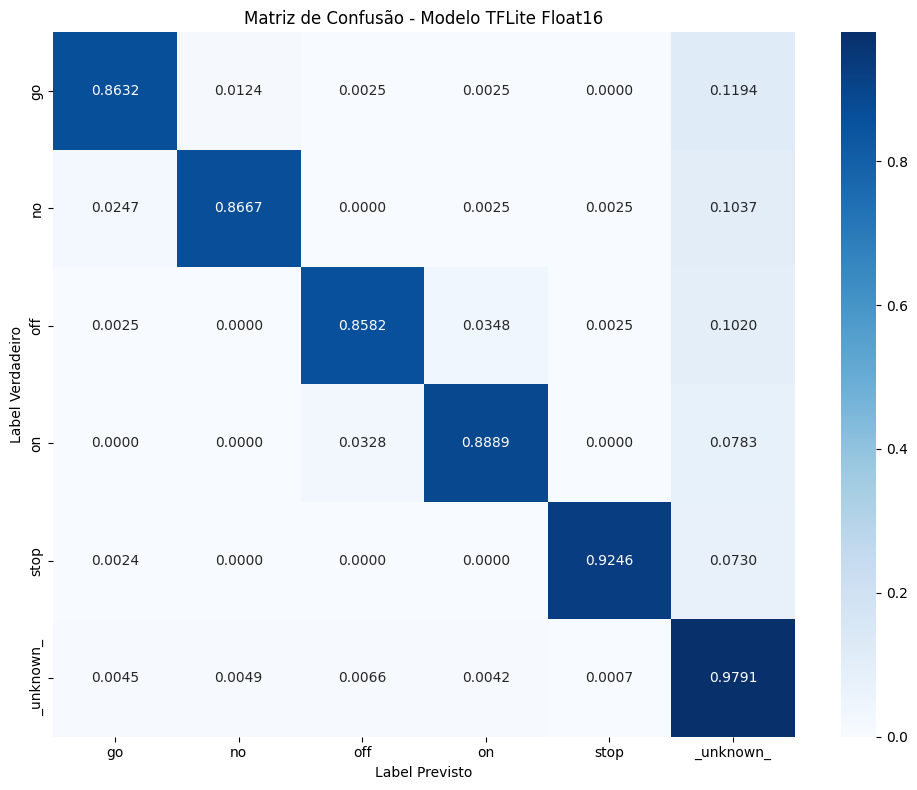

In [38]:
cm = confusion_matrix(y_true, y_pred)
row_sums = cm.sum(axis=1, keepdims=True)
cm_normalized = cm.astype('float') / row_sums

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.4f',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title('Matriz de Confusão - Modelo TFLite Float16')
plt.ylabel('Label Verdadeiro')
plt.xlabel('Label Previsto')
plt.tight_layout()
plt.show()

### MFCC:

In [40]:
TFLITE_MODEL_PATH = Path('../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel_&_MFCC/models/model_MFCC_fp16.tflite')

print(f"Carregando modelo TFLite de: {TFLITE_MODEL_PATH}")
interpreter = tf.lite.Interpreter(model_path=str(TFLITE_MODEL_PATH))

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

print("\n--- Detalhes do Modelo TFLite ---")
print(f"Entrada (Shape): {input_details['shape']}")
print(f"Entrada (Tipo): {input_details['dtype']}")
print(f"Saída (Shape): {output_details['shape']}")
print(f"Saída (Tipo): {output_details['dtype']}")

Carregando modelo TFLite de: ../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel_&_MFCC/models/model_MFCC_fp16.tflite

--- Detalhes do Modelo TFLite ---
Entrada (Shape): [ 1 97 13  1]
Entrada (Tipo): <class 'numpy.float32'>
Saída (Shape): [1 6]
Saída (Tipo): <class 'numpy.float32'>


In [41]:
y_true = []
y_pred = []
total_samples = 0

print("Iniciando avaliação no dataset de teste...")
for data_batch, labels_batch in test_ds_MFCC:
    # Iterar sobre cada amostra no lote
    for i in range(data_batch.shape[0]):
        # Pegar uma única amostra de dado
        sample_data = data_batch[i]
        
        # Adicionar a dimensão do lote (batch dimension) para corresponder ao shape da entrada do modelo
        input_tensor = np.expand_dims(sample_data, axis=0).astype(np.float32)

        # Definir o tensor de entrada, executar inferência e obter a saída
        # Não precisamos de nenhuma conversão manual, o interpretador cuida de tudo.
        interpreter.set_tensor(input_details['index'], input_tensor)
        interpreter.invoke()
        output_data = interpreter.get_tensor(output_details['index'])
        
        # Armazenar o rótulo previsto e o rótulo verdadeiro
        predicted_label_index = np.argmax(output_data)
        y_pred.append(predicted_label_index)
        y_true.append(labels_batch[i].numpy())
        
    total_samples += data_batch.shape[0]
    print(f"Avaliadas {total_samples} amostras...")

print("\nAvaliação concluída.")

Iniciando avaliação no dataset de teste...
Avaliadas 64 amostras...
Avaliadas 128 amostras...
Avaliadas 192 amostras...
Avaliadas 256 amostras...
Avaliadas 320 amostras...
Avaliadas 384 amostras...
Avaliadas 448 amostras...
Avaliadas 512 amostras...
Avaliadas 576 amostras...
Avaliadas 640 amostras...
Avaliadas 704 amostras...
Avaliadas 768 amostras...
Avaliadas 832 amostras...
Avaliadas 896 amostras...
Avaliadas 960 amostras...
Avaliadas 1024 amostras...
Avaliadas 1088 amostras...
Avaliadas 1152 amostras...
Avaliadas 1216 amostras...
Avaliadas 1280 amostras...
Avaliadas 1344 amostras...
Avaliadas 1408 amostras...
Avaliadas 1472 amostras...
Avaliadas 1536 amostras...
Avaliadas 1600 amostras...
Avaliadas 1664 amostras...
Avaliadas 1728 amostras...
Avaliadas 1792 amostras...
Avaliadas 1856 amostras...
Avaliadas 1920 amostras...
Avaliadas 1984 amostras...
Avaliadas 2048 amostras...
Avaliadas 2112 amostras...
Avaliadas 2176 amostras...
Avaliadas 2240 amostras...
Avaliadas 2304 amostras...
A

In [42]:
print("\n--- Relatório de Classificação ---\n")
report = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
print(report)


--- Relatório de Classificação ---

              precision    recall  f1-score   support

          go       0.91      0.89      0.90       402
          no       0.79      0.97      0.87       405
         off       0.94      0.91      0.92       402
          on       0.93      0.92      0.92       396
        stop       0.98      0.92      0.95       411
   _unknown_       0.96      0.95      0.96      2874

    accuracy                           0.94      4890
   macro avg       0.92      0.92      0.92      4890
weighted avg       0.94      0.94      0.94      4890



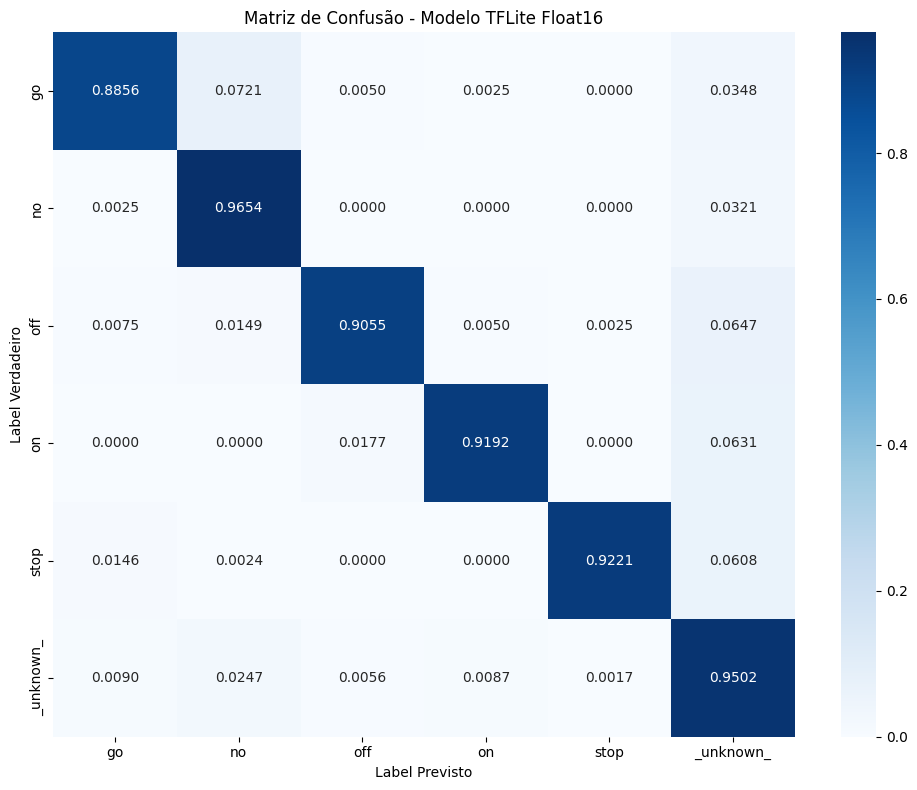

In [43]:
cm = confusion_matrix(y_true, y_pred)
row_sums = cm.sum(axis=1, keepdims=True)
cm_normalized = cm.astype('float') / row_sums

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.4f',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title('Matriz de Confusão - Modelo TFLite Float16')
plt.ylabel('Label Verdadeiro')
plt.xlabel('Label Previsto')
plt.tight_layout()
plt.show()